#### 데이터 로드

In [1]:
# 데이터 확인
import pandas as pd

df = pd.read_csv('news_preprocessed_economy.csv')
df.head()

,title,content,date,press,url,text,clean_text,tokens
0,"몽키트래블, 태국 호텔 예약 혜택 확대",동남아 전문 여행사 몽키트래블이 태국 호텔 예약 서비스에서 전용 혜택을 확대했다고 ...,2026-03-26 17:41:00,머니투데이,https://n.news.naver.com/mnews/article/008/000...,"몽키트래블, 태국 호텔 예약 혜택 확대 동남아 전문 여행사 몽키트래블이 태국 호텔...",몽키트래블 태국 호텔 예약 혜택 확대 동남아 전문 여행사 몽키트래블이 태국 호텔 예...,"['몽키트래블', '태국', '호텔', '예약', '혜택', '확대', '동남아',..."
1,"일가족 사망 비극에…복지부, 경찰·교수 만나 '자살 시도자' 대응 논의",최근 일가족이 자살로 사망하는 사건이 발생한 가운데 보건복지부가 26일 오전 한국생...,2026-03-26 17:41:00,머니투데이,https://n.news.naver.com/mnews/article/008/000...,"일가족 사망 비극에…복지부, 경찰·교수 만나 '자살 시도자' 대응 논의 최근 일가족...",일가족 사망 비극에 복지부 경찰 교수 만나 자살 시도자 대응 논의 최근 일가족이 자...,"['일가족', '사망', '비극', '복지부', '경찰', '교수', '만나', '..."
2,"국민성장펀드, 리벨리온에 2500억 첫 직접 투자","""K엔비디아 육성할 것""\nAI 반도체 스타트업 지원\n국민성장펀드가 이른바 'K엔...",2026-03-26 17:41:00,매일경제,https://n.news.naver.com/mnews/article/009/000...,"국민성장펀드, 리벨리온에 2500억 첫 직접 투자 ""K엔비디아 육성할 것""\nAI ...",국민성장펀드 리벨리온에 억 첫 직접 투자 엔비디아 육성할 것 반도체 스타트업 지원 ...,"['국민', '성장', '펀드', '직접', '투자', '엔비디아', '육성', '..."
3,"LS에코에너지·호주 라이너스, 300억 CB 교환 '희토류 동맹'",LS에코에너지는 글로벌 희토류 원료 공급 2위 기업인 호주 라이너스와 상호 투자에 ...,2026-03-26 17:41:00,한국경제,https://n.news.naver.com/mnews/article/015/000...,"LS에코에너지·호주 라이너스, 300억 CB 교환 '희토류 동맹' LS에코에너지는 ...",에코에너지 호주 라이너스 억 교환 희토류 동맹 에코에너지는 글로벌 희토류 원료 공급...,"['에코', '에너지', '호주', '라이너스', '교환', '희토', '동맹', ..."
4,한화생명 판매법인 분리 5년…연봉 1억 넘는 설계사 5606명,한화생명금융서비스가 출범 5년 만에 매출 2조4379억원을 기록했다.\n26일 한화...,2026-03-26 17:41:00,매일경제,https://n.news.naver.com/mnews/article/009/000...,한화생명 판매법인 분리 5년…연봉 1억 넘는 설계사 5606명 한화생명금융서비스가 ...,한화생명 판매법인 분리 년 연봉 억 넘는 설계사 명 한화생명금융서비스가 출범 년 만...,"['한화생명', '판매', '법인', '분리', '연봉', '설계사', '한화생명'..."


In [2]:
# tokens를 실제 리스트 형식으로 변환
import ast

df["tokens"] = df["tokens"].apply(ast.literal_eval)

#### 1️⃣ Dictionary 생성 (단어 → ID)

In [3]:
from gensim.corpora import Dictionary

dictionary = Dictionary(df["tokens"])

# 너무 일반적인 단어 제거
dictionary.filter_extremes(no_below=5, no_above=0.5)

#### 2️⃣ Corpus 생성 (문서 → 단어 빈도 벡터)

In [4]:
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

#### 3️⃣ LDA 모델 학습

In [5]:
# 1. 최적의 토픽 개수 탐색
from gensim.models import LdaModel
from gensim.models import CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10):
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=10,
            random_state=42
        )
        
        model_list.append(model)
        
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        
        coherence_values.append(coherencemodel.get_coherence())
    
    return model_list, coherence_values


In [6]:
# 2. 실행
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=df["tokens"],
    start=2,
    limit=10
)


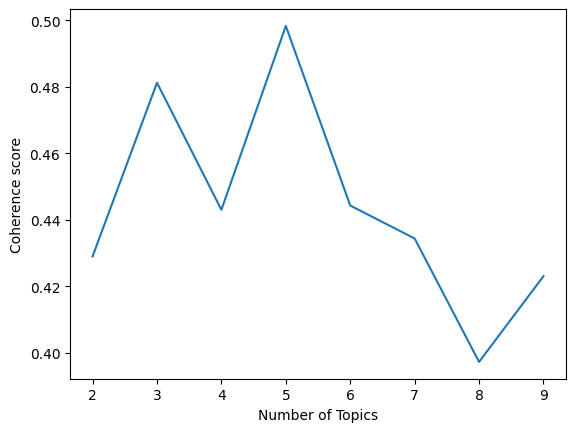

In [7]:
# 3. 시각화
import matplotlib.pyplot as plt

x = range(2,10)

plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.show()


In [8]:
# 4. 최적 토픽 개수 선택
best_index = coherence_values.index(max(coherence_values))
lda_model = model_list[best_index]

print("최적 토픽 개수:", best_index + 2)
print("Coherence score:", max(coherence_values))


최적 토픽 개수: 5
Coherence score: 0.4983306786923575


#### 4️⃣ 토픽 확인

In [9]:
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)

(0, '0.013*"기업" + 0.012*"투자" + 0.010*"금융" + 0.009*"사업" + 0.009*"지역" + 0.009*"산업" + 0.007*"규모" + 0.006*"성장" + 0.006*"펀드" + 0.006*"시장"')
(1, '0.016*"기업" + 0.010*"시장" + 0.008*"혁신" + 0.006*"사업" + 0.006*"확대" + 0.006*"의약품" + 0.006*"브랜드" + 0.006*"국내" + 0.006*"투자" + 0.005*"제약"')
(2, '0.017*"가격" + 0.010*"시장" + 0.009*"거래" + 0.008*"주택" + 0.008*"기술" + 0.007*"메모리" + 0.007*"서울" + 0.007*"상승" + 0.007*"업체" + 0.007*"계란"')
(3, '0.041*"가격" + 0.017*"최고" + 0.016*"중동" + 0.016*"경제" + 0.016*"전망" + 0.012*"인하" + 0.012*"전쟁" + 0.012*"물가" + 0.011*"석유" + 0.010*"휘발유"')
(4, '0.022*"금융" + 0.021*"주주" + 0.020*"이사" + 0.015*"대표" + 0.012*"선임" + 0.008*"총회" + 0.007*"주식" + 0.007*"회장" + 0.007*"배당" + 0.007*"안건"')


In [10]:
# 토픽 이름 정의
topic_names = {
0: "기업 투자 및 산업 성장",
1: "제약·바이오 산업 및 혁신",
2: "시장 가격 및 실물경제 동향",
3: "국제 정세와 에너지·물가 영향",
4: "기업 지배구조 및 주주총회"
}

#### 5️⃣ 각 기사별 토픽 비중 계산

In [11]:
doc_topics = [lda_model.get_document_topics(doc) for doc in corpus]

#### 6️⃣ DataFrame에 토픽 추가

In [12]:
df["dominant_topic"] = [
    max(topic, key=lambda x: x[1])[0] for topic in doc_topics
]

In [13]:
# 토픽별 대표 기사 확인
for topic in range(6):
    print(f"\n=== Topic {topic} 대표 기사 ===")
    print(df[df["dominant_topic"] == topic]["title"].head(5))


=== Topic 0 대표 기사 ===
1      일가족 사망 비극에…복지부, 경찰·교수 만나 '자살 시도자' 대응 논의
2                  국민성장펀드, 리벨리온에 2500억 첫 직접 투자
9                     공모주 시장 뜨거운데, 상장 예심은 뜸해졌다
14                         정기선 "문제의 답은 현장에 있다"
16    ‘K-엔비디아’ 첫 투자…국민성장펀드, 리벨리온에 2500억 직접 넣는다
Name: title, dtype: object

=== Topic 1 대표 기사 ===
0                    몽키트래블,  태국 호텔 예약 혜택 확대
7      와디즈, 신규 메이커 수수료 30% 할인…AI·데이터 기능도 강화
10    '차남' 한화생명 김동원 사장도 결혼…3형제 모두 '일반인·비공개'
12            "사주 보러 한국 왔어요"...카드사 해외카드 수익↑
15            인디·글로벌 다 몰렸다…무신사 ‘넥스트 뷰티’ 속도전
Name: title, dtype: object

=== Topic 2 대표 기사 ===
3     LS에코에너지·호주 라이너스, 300억 CB 교환 '희토류 동맹'
11                 강남 떨어지는데 외곽은…집값 온도차, 왜?
50    "강남은 어차피 못사"… 강북 아파트는 실수요자 몰려 신고가 속출
51                  강남은 하락, 외곽은 신고가…정책의 역설
54         양도세 중과 코앞, 10억 뚝뚝 … 퍼렇게 질린 한강벨트
Name: title, dtype: object

=== Topic 3 대표 기사 ===
28     27일 0시부터 유류세 추가 인하…리터당 휘발유 65원·경유 87원↓
40         "포장지 없어 식품 생산 중단할 판"…'초유의 상황' 벌어졌다
46    리터당 경유 87원·휘발유 65원 유류세 추가↓…최고가는 오른다(종합)
59        세계경제, 여전히

In [14]:
# 토픽 이름 추가
df["topic_name"] = df["dominant_topic"].map(topic_names)

In [15]:
# 전체 뉴스 토픽 분포
topic_distribution = df["dominant_topic"].value_counts(normalize=True)
print(topic_distribution)

dominant_topic
3    0.251316
0    0.221053
1    0.197368
2    0.165789
4    0.164474
Name: proportion, dtype: float64


#### 7️⃣ 언론사별 토픽 분포 분석

In [16]:
topic_press = pd.crosstab(df["press"], df["dominant_topic"])

In [17]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(topic_press)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 212.6519767318723
p-value: 2.559805234513385e-12


In [18]:
# 비율로 보기
topic_press_ratio = topic_press.div(topic_press.sum(axis=1), axis=0)

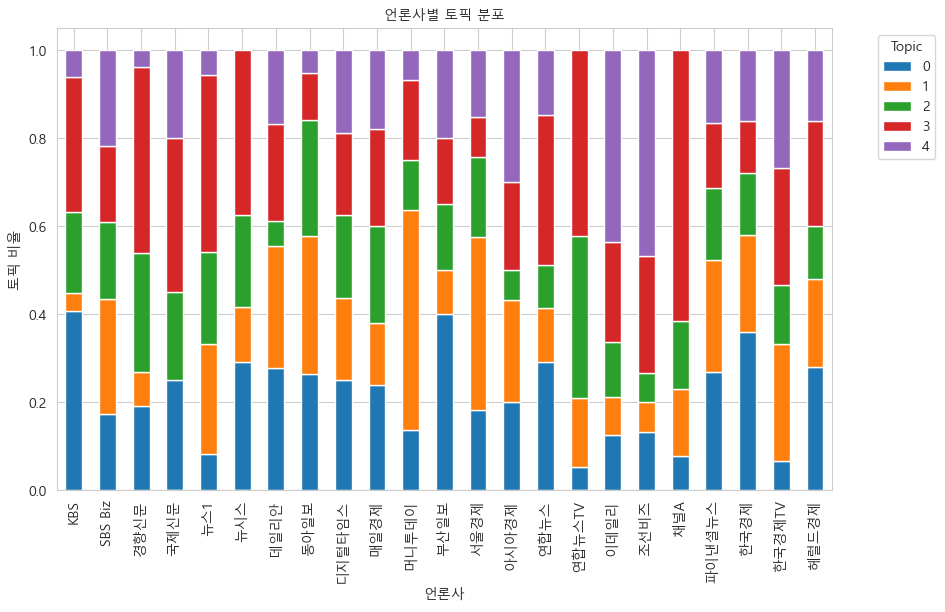

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

topic_press_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("언론사별 토픽 분포", fontproperties=font_prop)
plt.xlabel("언론사", fontproperties=font_prop)
plt.ylabel("토픽 비율", fontproperties=font_prop)

plt.legend(title="Topic", bbox_to_anchor=(1.05,1))

plt.show()

#### 8️⃣ 토픽 키워드 표 생성

In [21]:
topic_keywords = {}

for i in range(5):
    words = lda_model.show_topic(i, topn=10)
    topic_keywords[i] = [w[0] for w in words]

topic_df = pd.DataFrame(topic_keywords).T
topic_df

,0,1,2,3,4,5,6,7,8,9
0,기업,투자,금융,사업,지역,산업,규모,성장,펀드,시장
1,기업,시장,혁신,사업,확대,의약품,브랜드,국내,투자,제약
2,가격,시장,거래,주택,기술,메모리,서울,상승,업체,계란
3,가격,최고,중동,경제,전망,인하,전쟁,물가,석유,휘발유
4,금융,주주,이사,대표,선임,총회,주식,회장,배당,안건


#### 9️⃣ 결과 저장

In [22]:
# news_lda_result.csv: 각 뉴스 기사가 어떤 토픽에 할당됐는지 저장한 파일
# press_topic_ratio.csv: 언론사별 토픽 비율(토픽 분포)을 저장한 파일

In [23]:
# 결과 파일 저장
df.to_csv("news_lda_result.csv", index=False)
topic_press_ratio.to_csv("press_topic_ratio.csv")

In [24]:
# 모델 저장
import joblib

joblib.dump(lda_model, "lda_model.pkl")
joblib.dump(dictionary, "dictionary.pkl")

['dictionary.pkl']